# Estudio comparativo del algoritmo Epsilon-Greedy


## Introducción



El algoritmo **Epsilon-Greedy** es uno de los métodos más fundamentales y utilizados para abordar el problema del dilema exploración-explotación en el aprendizaje por refuerzo.

La idea básica es equilibrar dos objetivos competitivos:
1.  **Explotación**: Elegir la acción que, según nuestro conocimiento actual, tiene la mayor recompensa estimada ($Q_t(a)$).
2.  **Exploración**: Elegir una acción diferente (potencialmente al azar) para recopilar más información sobre el entorno y refinar nuestras estimaciones.

El algoritmo funciona con un parámetro $\epsilon$ (epsilon), donde $0 \le \epsilon \le 1$. En cada paso $t$:
*   Con probabilidad $1 - \epsilon$, el agente selecciona la acción *greedy* (avariciosa): $A_t = \arg\max_a Q_t(a)$.
*   Con probabilidad $\epsilon$, el agente selecciona una acción aleatoria de entre todas las $k$ acciones posibles con probabilidad uniforme.

Matemáticamente, la probabilidad de seleccionar una acción $a$ es:
$$ 
\pi_t(a) = \begin{cases} 
(1 - \epsilon) + \frac{\epsilon}{k} & \text{si } a = A^*_t \text{ (acción greedy)} \\
\frac{\epsilon}{k} & \text{si } a \neq A^*_t 
\end{cases}
$$

En este estudio analizaremos el comportamiento de este algoritmo variando el valor de $\epsilon$. Un $\epsilon$ muy bajo favorece la explotación pero corre el riesgo de no encontrar la acción óptima rápidamente. Un $\epsilon$ alto asegura mucha exploración pero impide maximizar la recompensa a largo plazo.



En este estudio se analizará el algoritmo Epsilon-Greedy utilizando tres tipos de bandidos diferentes: Normal, Binomial y Bernoulli. Se establecerán parámetros comunes, se crearán los bandidos y se evaluará el rendimiento en términos de recompensa promedio, arrepentimiento (regret) y selección óptima.


## Preparación del entorno


In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    print("Ejecutando en Colab")
    !git clone https://github.com/mlucasumu/EML_RL_LucasOrtiz.git
    %cd EML_RL_LucasOrtiz/k_brazos
else:
   print("Ejecutando en local")

In [ ]:
# Librerías necesarias para el setup
import sys

# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv', '', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv\\Lib\\site-packages', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\EML_RL_LucasOrtiz\\k_brazos\\src']


In [2]:
# Importación de librerías y módulos
import numpy as np

from algorithms import EpsilonGreedy, EpsilonGreedyDecay
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales


A continuación, definimos la configuración experimental compartida por todas las pruebas. Se ha fijado una semilla aleatoria (`SEED`) para asegurar que los resultados sean reproducibles. Los entornos constan de bandidos con $k=6$ brazos, una cantidad seleccionada para facilitar la interpretación visual de las estadísticas individuales de cada acción. El horizonte temporal de cada simulación se ha limitado a 300 pasos de tiempo, un intervalo suficiente para observar la convergencia de los algoritmos evaluados. Para obtener estimaciones robustas, cada experimento se promedia sobre 500 ejecuciones independientes.

Adicionalmente, es importante destacar que la implementación de los agentes incorpora una etapa preliminar de **inicialización**. En esta fase, cada algoritmo acciona cada una de las palancas disponibles exactamente una vez antes de iniciar su estrategia de aprendizaje propiamente dicha. Se ha constatado experimentalmente que esta heurística de exploración inicial acelera y estabiliza significativamente el proceso de convergencia.


In [4]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos
runs = 500  # Número de ejecuciones

## Creación de los bandidos


En este apartado configuramos los tres bandidos necesarios para la comparativa.

### Bandido Normal


El primero de los bandidos se basa en brazos con distribución normal, manteniendo los valores predeterminados para la desviación estándar (entre 1 y 3). Sin embargo, hemos ajustado las medias a un rango más estrecho, entre 5 y 10. El objetivo de reducir esta dispersión entre medias es dificultar la identificación del brazo óptimo; al ralentizar la convergencia, podremos apreciar mejor las sutilezas y el rendimiento diferencial de cada algoritmo.

In [6]:
# Creación del bandit normal
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10))
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Como podemos observar en la salida de la celda anterior, el **Brazo 3** resulta ser el óptimo con una recompensa esperada de **9.98**. Las medias de los otros brazos oscilan entre 7.59 y 8.77, lo que presenta un desafío moderado para diferenciar el mejor brazo debido a la varianza inherente ($\sigma$ entre 1.01 y 2.8).


### Bandido Binomial


La probabilidad de éxito oscila entre 0.1 y 0.9, mientras que el número de experimentos $n$ se mueve entre 5 y 15.


In [7]:
# Creación del bandit binomial
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15))
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


En el caso del bandido Binomial, el **Brazo 2** es el óptimo con una recompensa esperada aproximada de **4.2**. Cabe destacar que este brazo tiene $n=6$ y $p=0.7$, lo cual supera a otras combinaciones como el Brazo 3 ($n=10, p=0.22$) a pesar de tener un $n$ menor, demostrando la importancia de la probabilidad de éxito.


### Bandido Bernoulli


En este caso, dejamos los parámetros del bandido por defecto (probabilidad de éxito entre 0.1 y 0.9).

In [8]:
# Creación del bandit bernoulli
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


Para el bandido Bernoulli, el **Brazo 2** se destaca claramente como la opción óptima con una probabilidad de éxito $p=0.9$. Dado que el siguiente mejor brazo tiene $p=0.7$, existe una separación clara ('gap') de 0.2, lo que debería facilitar teóricamente la convergencia del algoritmo hacia la acción óptima.


## Análisis de Epsilon-Greedy


Probaremos tres configuraciones de $\epsilon$: $0$ (Greedy puro), $0.01$ (Baja exploración) y $0.1$ (Exploración moderada).

La metodología experimental aplicada para evaluar estas configuraciones se detalla a continuación:

1.  **Variación del Parámetro $\epsilon$**: Se comparan escenarios representativos del compromiso exploración-explotación:
    *   **$\epsilon = 0$ (Greedy puro)**: El agente nunca explora, limitándose a explotar la acción con mayor valor estimado inicial o descubierto por azar. Sirve como línea base de explotación pura.
    *   **$\epsilon = 0.01$ (Baja exploración)**: Introduce una pequeña probabilidad para explorar, permitiendo refinar las estimaciones a largo plazo con un costo mínimo en recompensas inmediatas.
    *   **$\epsilon = 0.1$ (Exploración moderada)**: Aumenta significativamente la frecuencia de exploración. Se espera que encuentre la acción óptima más rápidamente, aunque su rendimiento asintótico podría ser menor debido a la exploración continua de acciones subóptimas.

2.  **Métricas de Evaluación**: El desempeño se medirá utilizando tres indicadores clave:
    *   **Recompensa Promedio**: Evolución de la ganancia media paso a paso. Útil para observar la velocidad de aprendizaje y la estabilidad.
    *   **Porcentaje de Selección Óptima**: Proporción de veces que el agente elige el brazo con la mayor media real. Es la métrica más directa de la "inteligencia" del agente.
    *   **Arrepentimiento Acumulado e Instantáneo**: Diferencia entre la recompensa obtenida y la máxima posible. El arrepentimiento logarítmico es deseable y caracteriza a los buenos algoritmos.

3.  **Robustez Experimental**: Todas las curvas y métricas presentadas son el promedio de **500 ejecuciones independientes** (runs). Esto suaviza la variabilidad estocástica inherente a los procesos de bandidos y garantiza que las conclusiones sean estadísticamente significativas.


In [8]:
algorithms_epsilon = [EpsilonGreedy(k=k, epsilon=0.0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

### Distribución Normal



In [7]:
np.random.seed(SEMILLA)
rewards_EN, optimal_selections_EN, cumulative_regret_per_algo_EN, rewards_per_arm_per_algo_EN = run_experiment(bandit_normal, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:09<00:00, 51.00it/s]


#### Análisis Detallado de Recompensa Promedio

La evolución temporal de la recompensa promedio ilustra la tensión fundamental del aprendizaje por refuerzo: el compromiso entre velocidad de convergencia y estabilidad asintótica. En general, esperaríamos ver lo siguiente:

*   **Estrategia $\epsilon=0.1$ (Exploración Moderada)**:
    *   **Fase Transitoria**: Exhibe la tasa de aprendizaje inicial más rápida. La exploración frecuente permite descubrir el brazo óptimo prematuramente.
    *   **Comportamiento Asintótico**: Sin embargo, su desempeño se ve acotado superiormente. Debido a que el agente está forzado a elegir una acción aleatoria el 10% de las veces, su recompensa promedio nunca puede converger al valor óptimo teórico ($q_*$), estabilizándose en un valor subóptimo (aproximadamente $0.9 \cdot q_* + 0.1 \cdot 	\text{promedio del resto}$).

*   **Estrategia $\epsilon=0.01$ (Exploración Conservadora)**:
    *   **Fase Transitoria**: El aprendizaje es más gradual. La menor frecuencia de exploración retrasa el descubrimiento inicial de la mejor acción.
    *   **Comportamiento Asintótico**: A largo plazo, esta estrategia domina. Al reducir el ruido de exploración, la política se aproxima más a la estrategia puramente codiciosa sobre el brazo óptimo, logrando una recompensa promedio superior y más estable.

*   **Estrategia $\epsilon=0$ (Greedy Puro)**:
    *   Se observa una alta dependencia de las condiciones iniciales. Al carecer de mecanismos para corregir estimaciones tempranas erróneas, el agente es propenso a converger prematuramente a ópimos locales, resultando en un desempeño global inferior y errático.

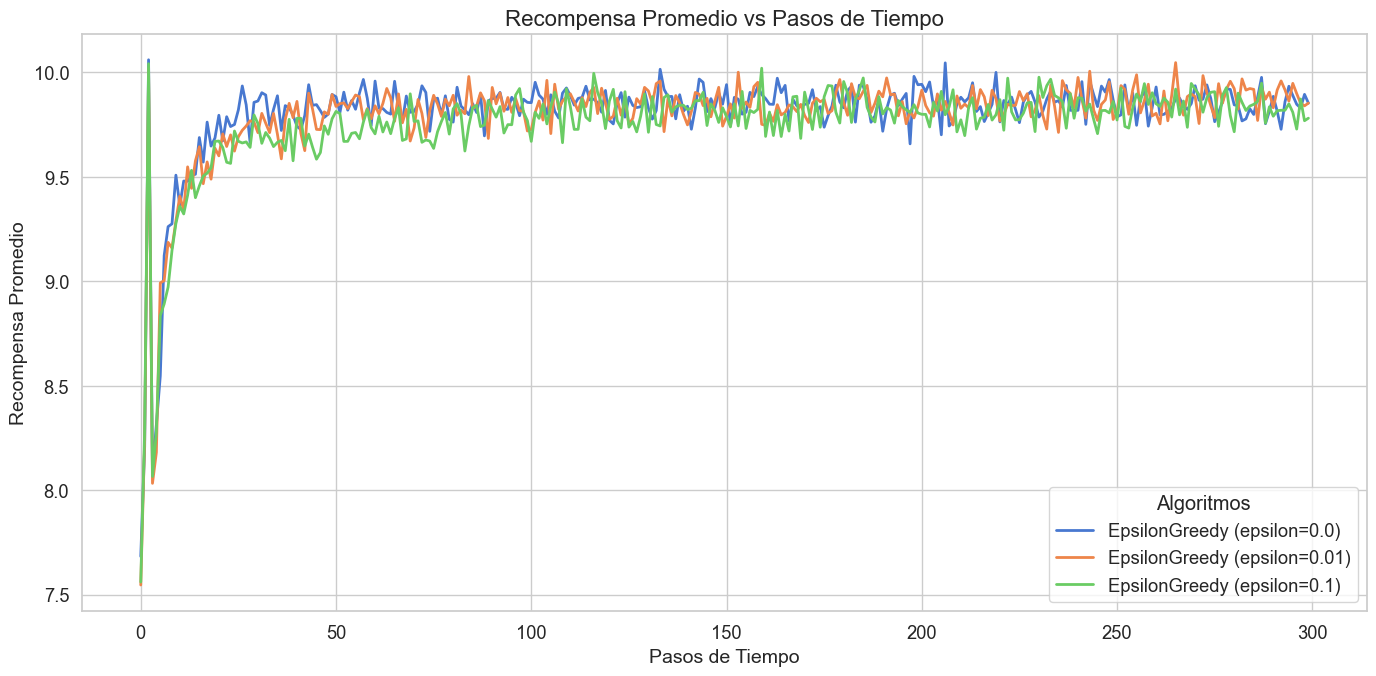

In [8]:
plot_average_rewards(steps, rewards_EN, algorithms_epsilon)

En este caso en particular, la diferencia entre las recompensas promedio de los tres algoritmos es poco perceptible a simple vista debido, probablemente, a la fase de inicialización en la que se elije cada brazo una vez. Aunque en esta gráfica es complicado determinar cuál es el mejor valor de epsilon, parece intuirse que el algoritmo con $\epsilon=0$ tiene una mayor velocidad de convergencia pero posiblemente deje de aprender antes que los demás, mientras que aquel con $\epsilon=0.1$ tiene una curva de aprendizaje algo más lenta pero lo más seguro es que continúe mejorando su solución durante toda la ejecución.

#### Análisis Detallado de Regret Acumulado

El *regret* acumulado cuantifica la diferencia entre la recompensa obtenida en cada paso por el agente y la que habría obtenido si hubiera escogido siempre el brazo óptimo. En esta gráfica es más sencillo discernir las diferencias entre los tres algoritmos, y podemos observar lo siguiente:

- Las tres curvas muestran una forma logarítmica, creciendo rápidamente al principio y después ralentizándose y reduciendo su pendiente poco a poco. No obstante, dado que los algoritmos se estabilizan en soluciones subóptimas, sus curvas tienen una forma prácticamente lineal a partir de cierto punto, debido a que dejan de aprender y, por tanto, el arrepentimiento instantáneo obtenido en un paso es casi el mismo que en el paso siguiente.
- El algoritmo con $\epsilon=0.01$ parece mostrar una reducción continuada de su pendiente durante toda la ejecución, con una curva que se hace cada vez más horizontal. Esto implica que continúa aprendiendo hasta el final, si bien lo hace lentamente.
- EL algoritmo que muestra un peor comportamiento (mayor *regret* acumulado) es aquel con $\epsilon=0.1$, mientras que aquel con $\epsilon=0.0$ tiene un arrepentimiento acumulado menor, lo cual resulta sorprendente debido a que un epsilon de 0.0 suele resultar en un estancamiento en soluciones pobres.

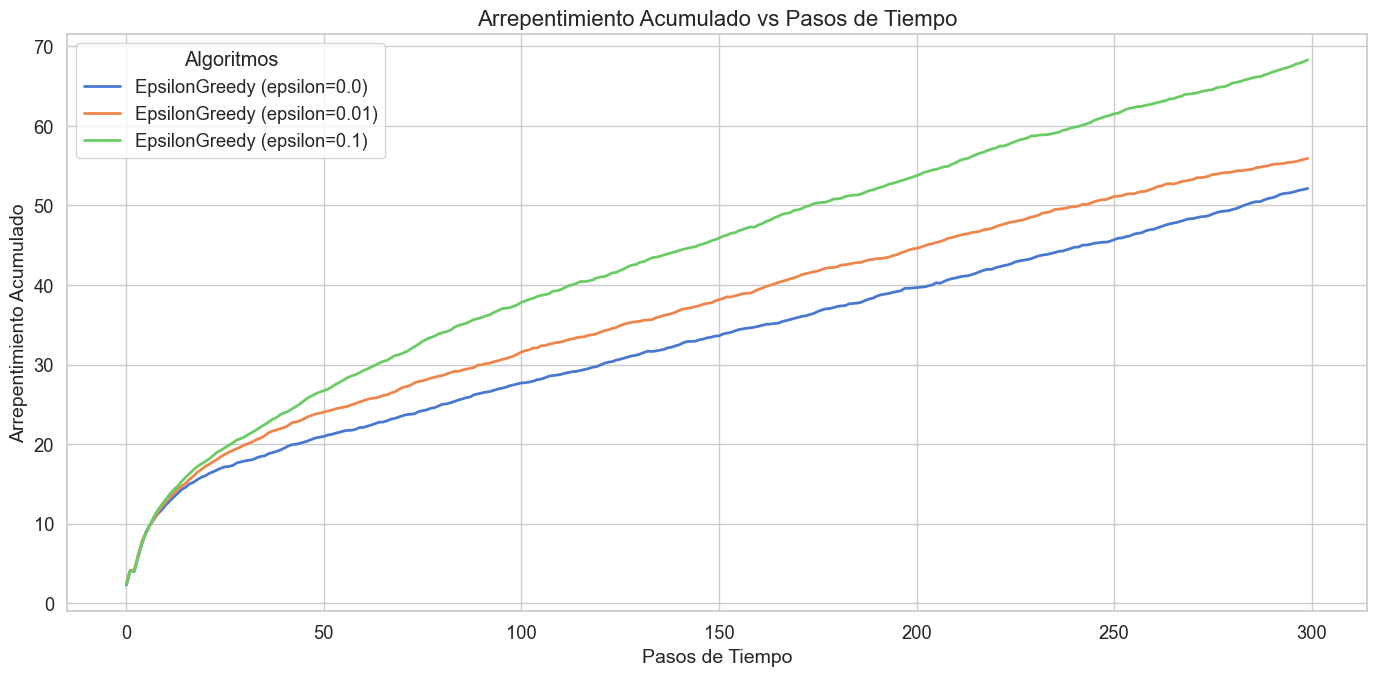

In [ ]:
plot_regret(steps, cumulative_regret_per_algo_EN, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

En la gráfica de porcentaje de selección del brazo óptimo podemos ver, como ya hemos dicho anteriormente, que el algoritmo con $\epsilon=0$ muestra un aprendizaje muy rápido y un elevado rendimiento, manteniéndose en un porcentaje similar al de los otros dos algoritmos. Como veíamos, el algoritmo con $\epsilon=0.1$ es el que aprende más lentamente, y se queda estancado aproximadamente en el mismo valor que el primer algoritmo, aunque su curva es más errática debido al componente aleatorio. Por último, esta gráfica confirma lo que ya comentábamos en la gráfica de arrepentimiento: el algoritmo con $\epsilon=0.01$ sigue aprendiendo durante toda la ejecución y en las últimas iteraciones su rendimiento empieza a ser superior al de los otros dos algoritmos.

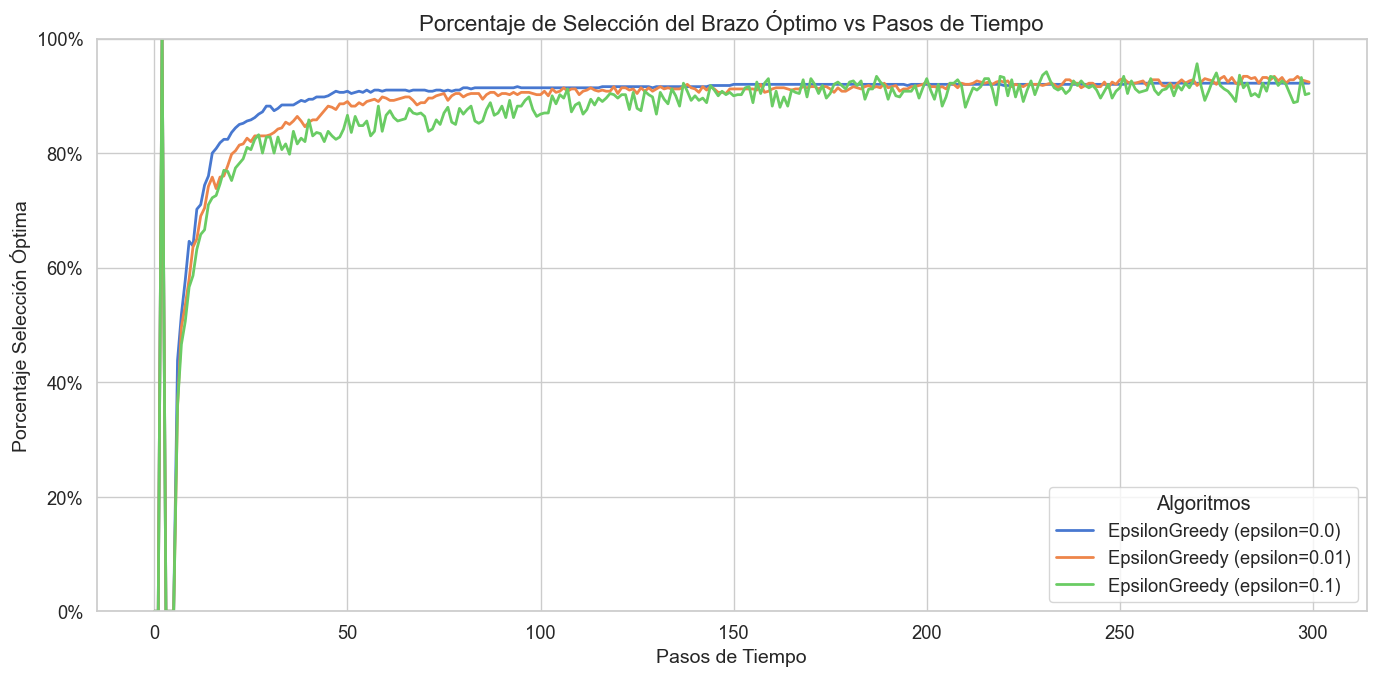

In [15]:
plot_optimal_selections(steps, optimal_selections_EN, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo

La distribución de selecciones por brazo al final del experimento revela la estructura de la política aprendida:

*   **Identificación del Óptimo**: Todos los métodos logran identificar el brazo con la media más alta (brazo óptimo) como la acción preferente, acumulando en él la gran mayoría de las selecciones.
*   **Diferencias en la exploración**: El algoritmo con $\epsilon=0.1$ selecciona los brazos subóptimos bastante más a menudo que los otros dos.

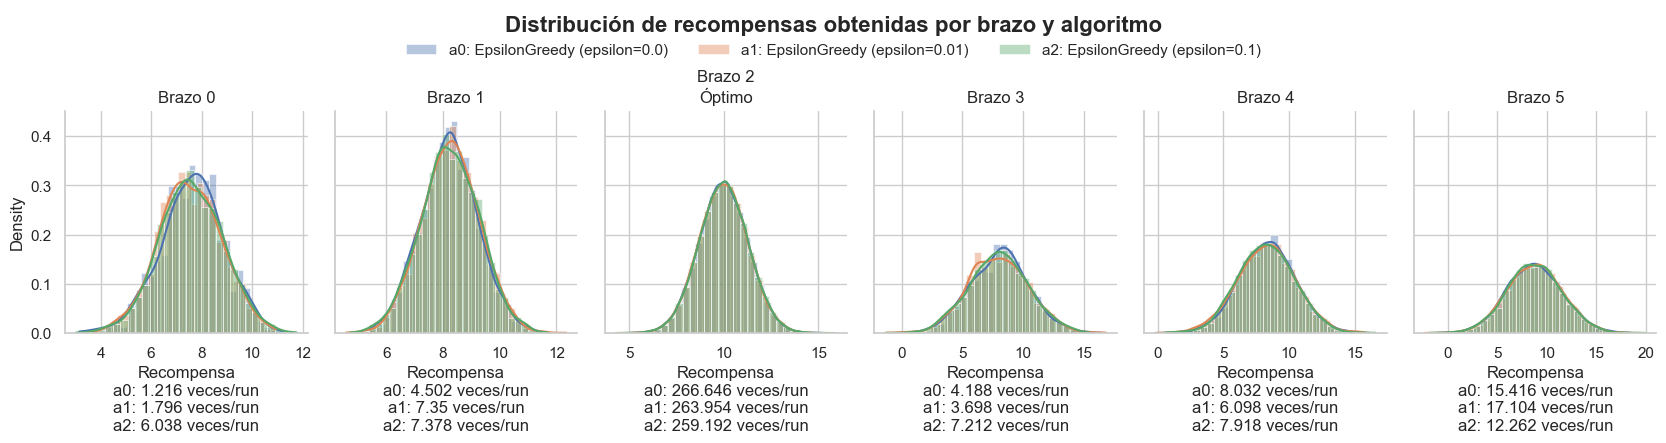

In [10]:
plot_arm_statistics(rewards_per_arm_per_algo_EN, algorithms_epsilon, runs, optimal_arm_normal)


Este gráfico ilustra la distribución de las recompensas obtenidas por cada algoritmo en cada brazo:
*   Permite visualizar no solo la media, sino la **varianza** real de cada brazo.
*   Nos ayuda a confirmar si el "Brazo Óptimo" identificado por el algoritmo coincide con el que tiene la media estadística más alta (Brazo 2 en esta configuración, o el que tenga mayor media según la semilla).
*   En el caso del Bandido Normal con medias cercanas, se puede apreciar el solapamiento entre las distribuciones, lo que explica la dificultad de los algoritmos para distinguirlos rápidamente.

### Distribución Binomial


In [16]:
np.random.seed(SEMILLA)
rewards_EBi, optimal_selections_EBi, cumulative_regret_per_algo_EBi, rewards_per_arm_per_algo_EBi = run_experiment(bandit_binomial, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:10<00:00, 46.22it/s]


#### Análisis Detallado de Recompensa Promedio
En el escenario Binomial, las recompensas son discretas y acotadas (éxitos en $n$ intentos), lo que reduce la varianza comparado con el caso Normal. Por lo general, lo que observamos es lo siguiente:

*   **Convergencia Rápida ($\epsilon=0.1$)**: Al igual que en el caso Normal, la estrategia con mayor exploración ($\epsilon=0.1$) logra un crecimiento inicial explosivo en la recompensa promedio. Sin embargo, su naturaleza estocástica impone un límite asintótico estricto, impidiéndole alcanzar el máximo teórico consistente.
*   **Dominio a Largo Plazo ($\epsilon=0.01$)**: La estrategia conservadora ($\epsilon=0.01$) demuestra su superioridad en el largo plazo. Tras un inicio más lento, supera a $\epsilon=0.1$, convergiendo a un valor de recompensa promedio más alto y estable, maximizando la explotación del brazo óptimo ($p \approx 0.9$).
*   **Estancamiento Greedy ($\epsilon=0$)**: La ausencia de exploración condena al agente a quedar atrapado frecuentemente en óptimos locales, resultando en un desempeño promedio significativamente inferior y altamente dependiente de la inicialización.

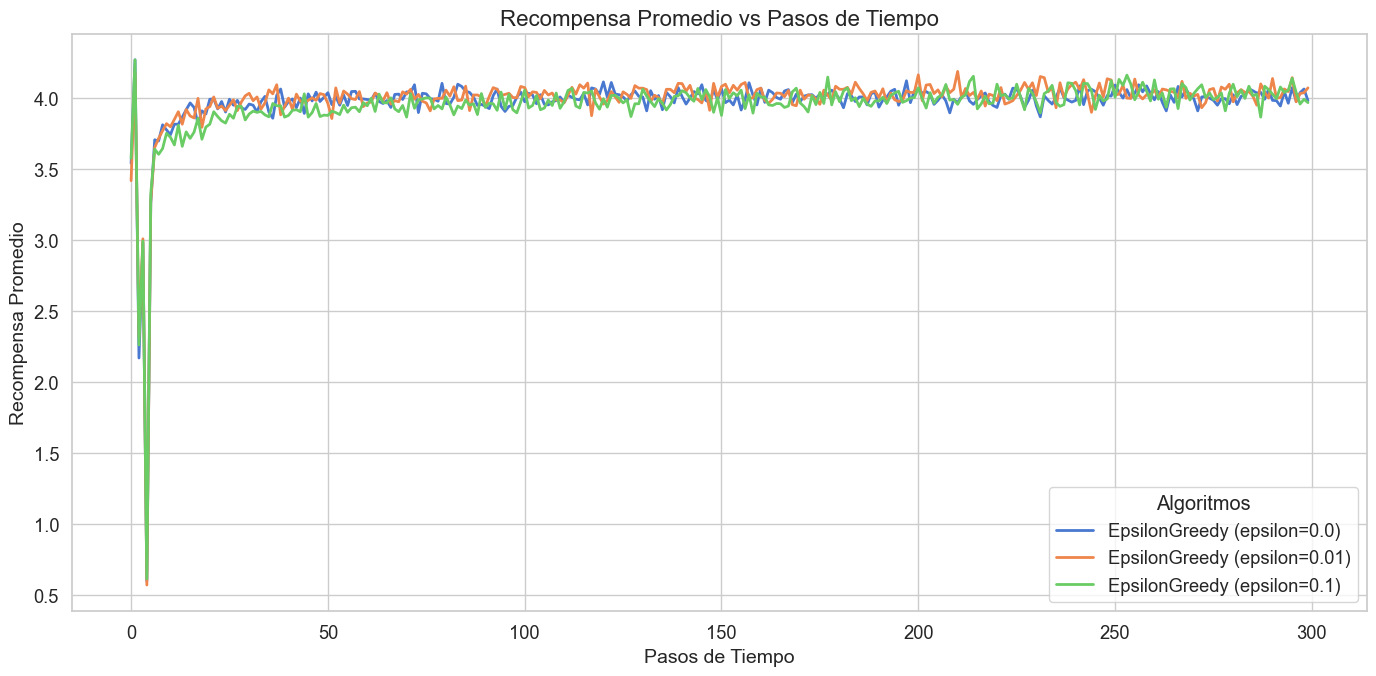

In [19]:
plot_average_rewards(steps, rewards_EBi, algorithms_epsilon)

En este caso en particular, posiblemente debido a la fase de inicialización de los algoritmos, el rendimiento de las tres versiones del algoritmo ha sido muy similar. Todos se han quedado alrededor de una recompensa promedio de 4.0, cercana a la recompensa esperada óptima de 4.2. Las velocidades de aprendizaje también son muy parecidas entre los tres algoritmos, y parece ser bastante más rápida que en el bandido normal.

#### Análisis Detallado de Regret Acumulado
El análisis del *regret* acumulado resalta el costo de la exploración continua: todos los algoritmos tienen un arrepentimiento que crece de manera prácticamente lineal durante toda la ejecución, y el cual nunca llegaría a disminuir su pendiente dado que el agente nunca puede dejar de seleccionar brazos subóptimos. En especial, el algoritmo con $\epsilon=0.1$ es aquel con mayor pendiente, como cabe esperar debido a su mayor exploración.

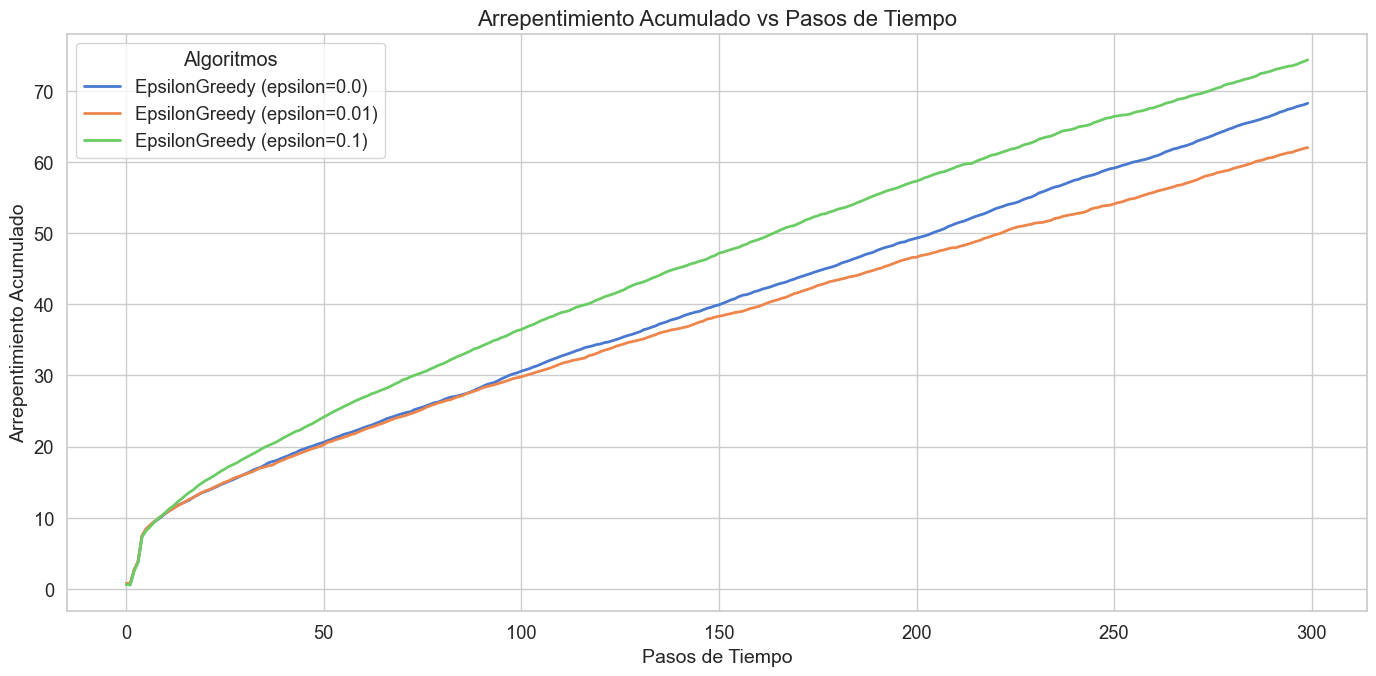

In [20]:
plot_regret(steps, cumulative_regret_per_algo_EBi, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

La métrica de selecciones óptimas muestra lo siguiente: el algoritmo con $\epsilon=0.0$ se estanca a partir de cierto procentaje y deja de crecer por completo, puesto que llega un momento en el que siempre selecciona la misma acción, posiblemente subóptima. En los otros dos casos, podemos observar que el porcentaje continúa ascendiendo durante toda la ejecución, especialmente en el caso de $\epsilon=0.1$, que parece aproximarse a un porcentaje del 90% de selección del brazo óptimo en la última iteración.

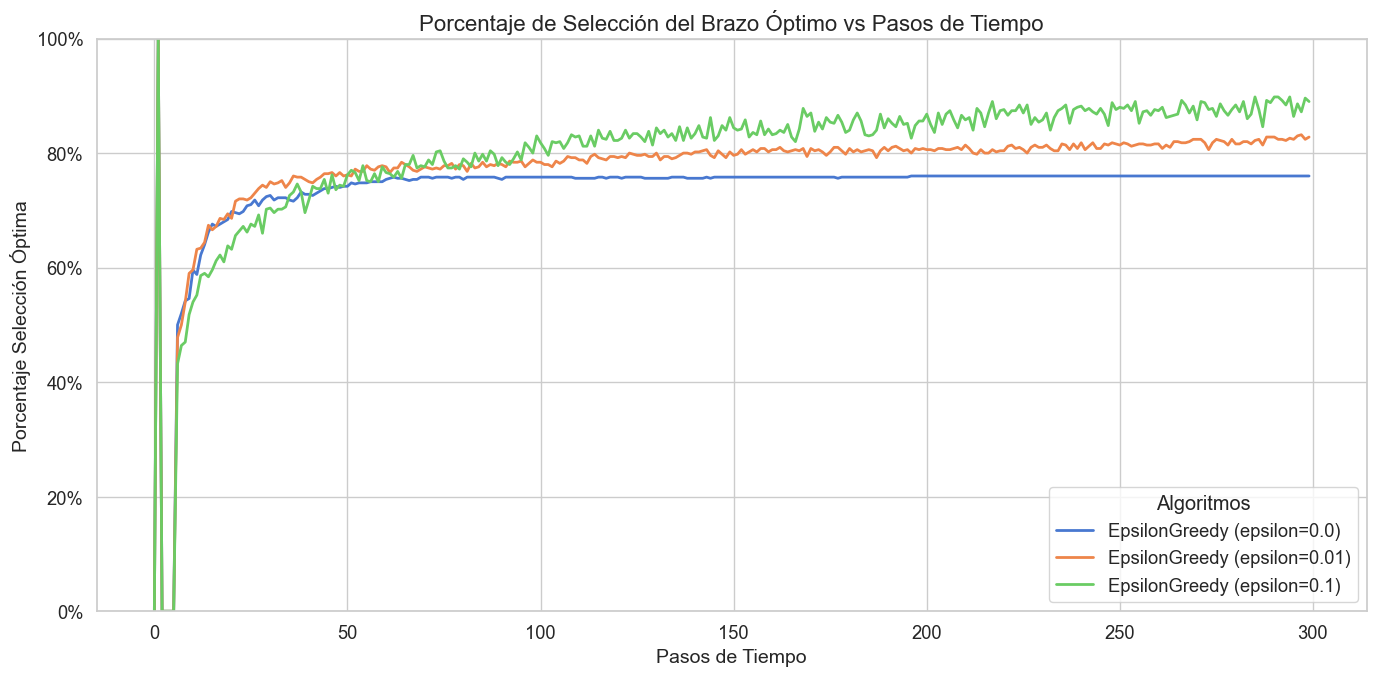

In [21]:
plot_optimal_selections(steps, optimal_selections_EBi, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo

Los diagramas ofrecen una visión granular de la distribución de decisiones del agente. Vemos que el algoritmo con $\epsilon=0$ es el que menos veces ha escogido el brazo óptimo de media, reaprtiéndose bastante más entre el segundo y tercer mejor brazo que el resto de algoritmos. El algoritmo con $\epsilon=0.01$ es el que más veces ha seleccionado el brazo óptimo, sin embargo, su continua exploración ha hecho que también sea el que más veces ha elegido el peor brazo (Brazo 4).

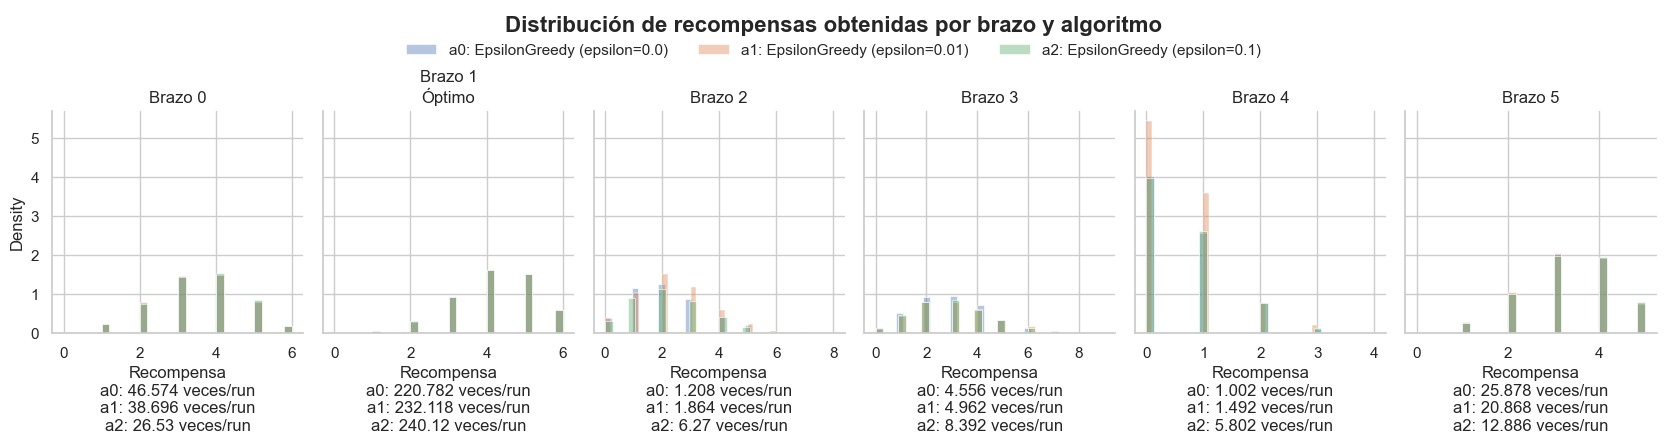

In [22]:
plot_arm_statistics(rewards_per_arm_per_algo_EBi, algorithms_epsilon, runs, optimal_arm_binomial, kde=False)

### Distribución Bernoulli


In [10]:
np.random.seed(SEMILLA)
rewards_EBe, optimal_selections_EBe, cumulative_regret_per_algo_EBe, rewards_per_arm_per_algo_EBe = run_experiment(bandit_bernoulli, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:09<00:00, 50.68it/s]


#### Análisis Detallado de Recompensa Promedio

En el bandido Bernoulli, la recompensa es binaria (0 o 1), lo que simplifica la estimación pero introduce una varianza constante basada en la probabilidad $p$. En la siguiente gráfica vemos cómo, de nuevo, los tres algoritmos han logrado converger a valores de recompensa promedio muy similares entre sí. No obstante, parece que $\text{EpsilonGreedy}(epsilon=0)$ se mantiene por debajo de los otros dos durante la mayor parte del proceso, mientras que el algoritmo con $\epsilon=0.1$ aparenta estar por encima.

También vemos que la naturaleza binaria de las recompensas (0 o 1) hace que las curvas sean más "ruidosas" visualmente que en los dos bandidos anteriores.

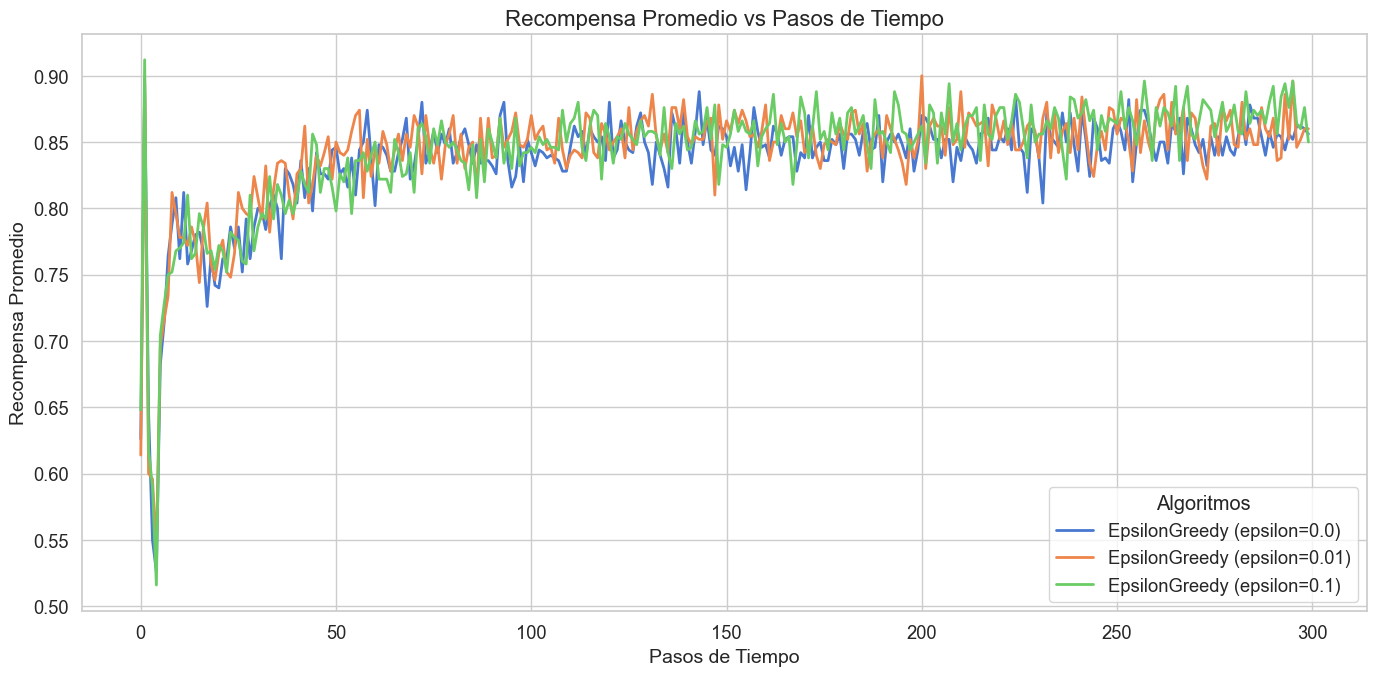

In [11]:
plot_average_rewards(steps, rewards_EBe, algorithms_epsilon)

#### Análisis Detallado de Regret Acumulado

El regret acumulado revela el costo oculto de las decisiones subóptimas: sucede algo similar a la distribución binomial, en la que los tres algoritmos se estancan rápidamente en una solución subóptima y, por tanto, las curvas de arrepentimiento tienen una forma casi lineal y bastante parecida entre los tres algoritmos. La curva con un comportamiento más logarítmico es la de $\text{EpsilonGreedy}(epsilon=0.1)$, cuya pendiente parece ir reduciéndose a lo largo de las 300 iteraciones, lo que indica que cada vez la diferencia entre la recompensa obtenida y la óptima es menor. De hecho, a pesar de que el algoritmo con $\epsilon=0.01$ tiene un arrepentiemiento menor durante gran parte del proceso, se observa cómo en las últimas iteraciones el algoritmo con $\epsilon=0.1$ comienza a tener un arrepentimiento más pequeño, lo que sugiere que este último aprende más lentamente en este caso, pero es capaz de llegar a mejores soluciones.

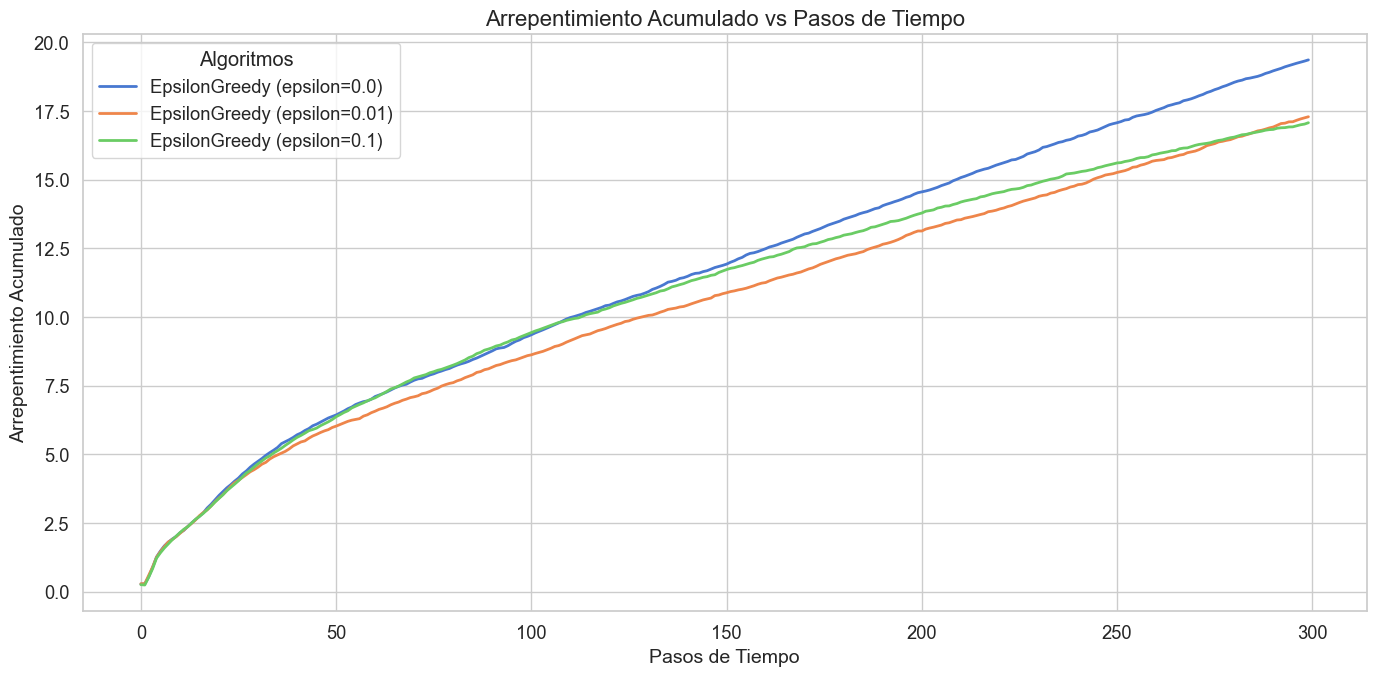

In [12]:
plot_regret(steps, cumulative_regret_per_algo_EBe, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

La curva de selecciones óptimas en Bernoulli es un indicador crítico de la capacidad del algoritmo para discernir probabilidades. A la vista de esta gráfica observamos que a los algoritmos $\epsilon$-greedy les cuesta más aprender cuál es el brazo óptimo que en los otros dos bandidos. Se aprecia que hay un valle bastante pronunciado alrededor la iteración 20 y los algoritmos no empiezan a estabilizarse hasta la iteración 75, aproximadamente.

En cuanto al rendimiento de cada algoritmo, vemos que $\epsilon=0$ muestra una meseta totalmente plana, indicando que el agente se ha comprometido irrevocablemente con una acción que considera óptima, sea cierto o no. La curva de $\epsilon=0.01$ asciende a valores más elevados que la anterior y continúa ascendiendo lentamente, pero es inferior al algoritmo con $\epsilon=0.1$, que alcanza valores próximos al 90% en la última iteración.

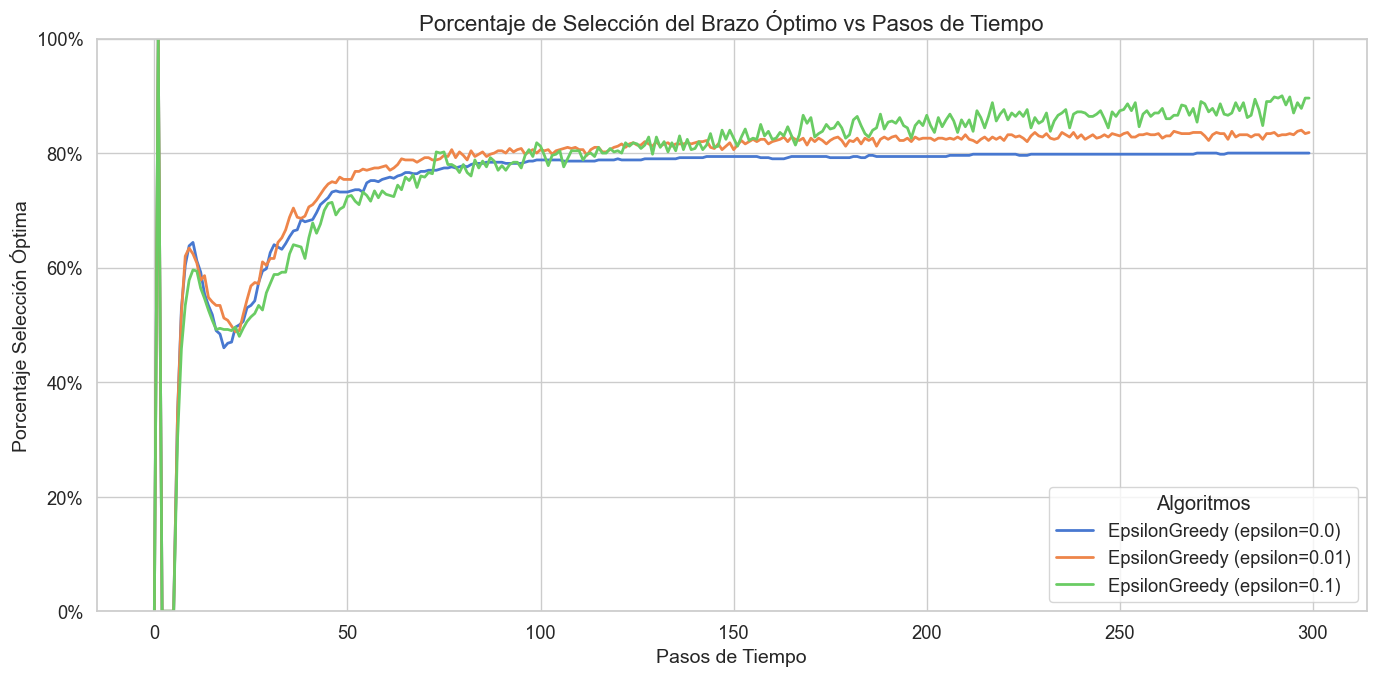

In [13]:
plot_optimal_selections(steps, optimal_selections_EBe, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo

La distribución final de las jugadas confirma la identificación del brazo objetivo: a pesar de la naturaleza binaria y ruidosa de la recompensa, todos los algoritmos logran acumular la gran mayoría de las selecciones en el brazo con mayor $p$. Apreciamos que el peor de los brazos (el Brazo 4) es el que menos veces ha sido escogido por todos los algoritmos, pero aquel con $\epsilon=0.1$ es el que más lo ha elegido debido, precisamente, a tener una mayor probabilidad de escoger una acción aleatoria. También vemos que $\epsilon=0$ es el que menos veces ha elegido el brazo óptimo de entre los tres algortimos, posiblemente porque en ocasiones ha identificado erróneamente que el mejor brazo era brazo 5 o el 0, que son el segundo y tercer mejor brazo, respectivamente.

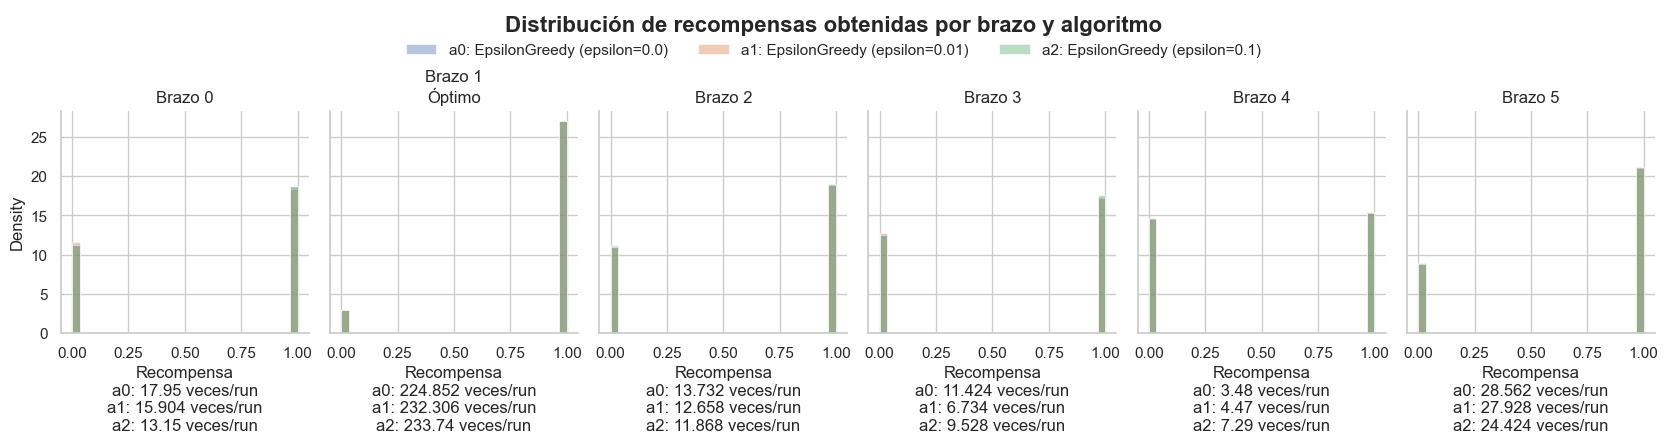

In [14]:
plot_arm_statistics(rewards_per_arm_per_algo_EBe, algorithms_epsilon, runs, optimal_arm_bernoulli, kde=False)

## Análisis de Epsilon-Decay

En esta sección vamos a hacer un estudio similar con el algoritmo Epsilon-Greedy con Decaimiento, el cual comienza con un valor inicial de $\epsilon$ y lo va disminuyendo en cada paso. De esta forma inicialmente se prima más la exploración pero, una vez el agente ya ha descubierto cuáles son los mejores brazos, se disminuye la exploración y se prioriza más la explotación. Concretamente, hacemos un decaimiento lineal de la siguiente forma:

$$ \epsilon_{t+1} = \max\{\epsilon_{\min}, \ \epsilon_t\cdot \lambda \}, $$

siendo $\lambda$ la tasa de decaimiento y $\epsilon_{\min}$ el menor valor posible del parámetro $\epsilon$.

En este caso, decidimos que el valor mínimo de $\epsilon$ fuese $0.001$ en todos los casos y probamos con tres tasas de decaimiento: $0.8$, $0.9$ y $0.99$. Dada la fórmula que hemos usado para realizar el decaimiento, cuanto mayor sea la tasa $\lambda$, más tardará $\epsilon$ en reducir su valor.

In [9]:
algorithms_decay = [EpsilonGreedyDecay(k=k, decay_rate=0.8, min_epsilon=0.001), 
                    EpsilonGreedyDecay(k=k, decay_rate=0.99, min_epsilon=0.001), 
                    EpsilonGreedyDecay(k=k, decay_rate=0.9999, min_epsilon=0.001)]

### Distribución Normal

Al igual que hicimos antes, comenzamos el estudio con el bandido de distribución normal.

In [106]:
np.random.seed(SEMILLA)
rewards_DN, optimal_selections_DN, cumulative_regret_per_algo_DN, rewards_per_arm_per_algo_DN = run_experiment(bandit_normal, algorithms_decay, steps, runs)

100%|██████████| 500/500 [00:20<00:00, 24.08it/s]


#### Análisis Detallado de Recompensa Promedio

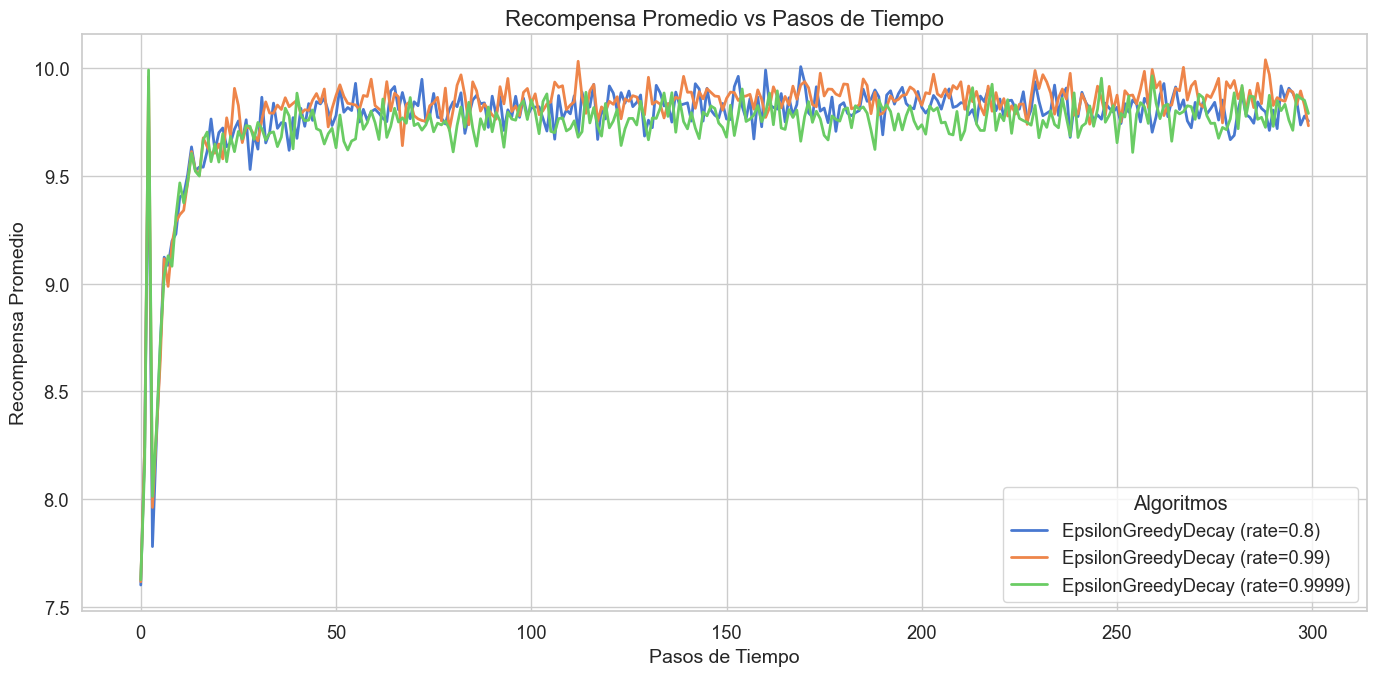

In [107]:
plot_average_rewards(steps, rewards_DN, algorithms_decay)

Observamos un comportamiento muy similar al algoritmo Epsilon Greedy: las tres versiones han logrado converger a un valor bastante próximo al óptimo (de 9.98), con diferencias poco notables a simple vista entre las tres. Aparentemente, la tasa de 0.9999 se mantiene por debajo de las otras dos versiones durante toda la ejecución, y la tasa de 0.99 parece alcanzar, en promedio, valores de recompensa algo más elevados. La velocidad de aprendizaje es bastante rápida en los tres casos, estabilizándose la recompensa alrededor del paso 40.

#### Análisis Detallado de Regret Acumulado

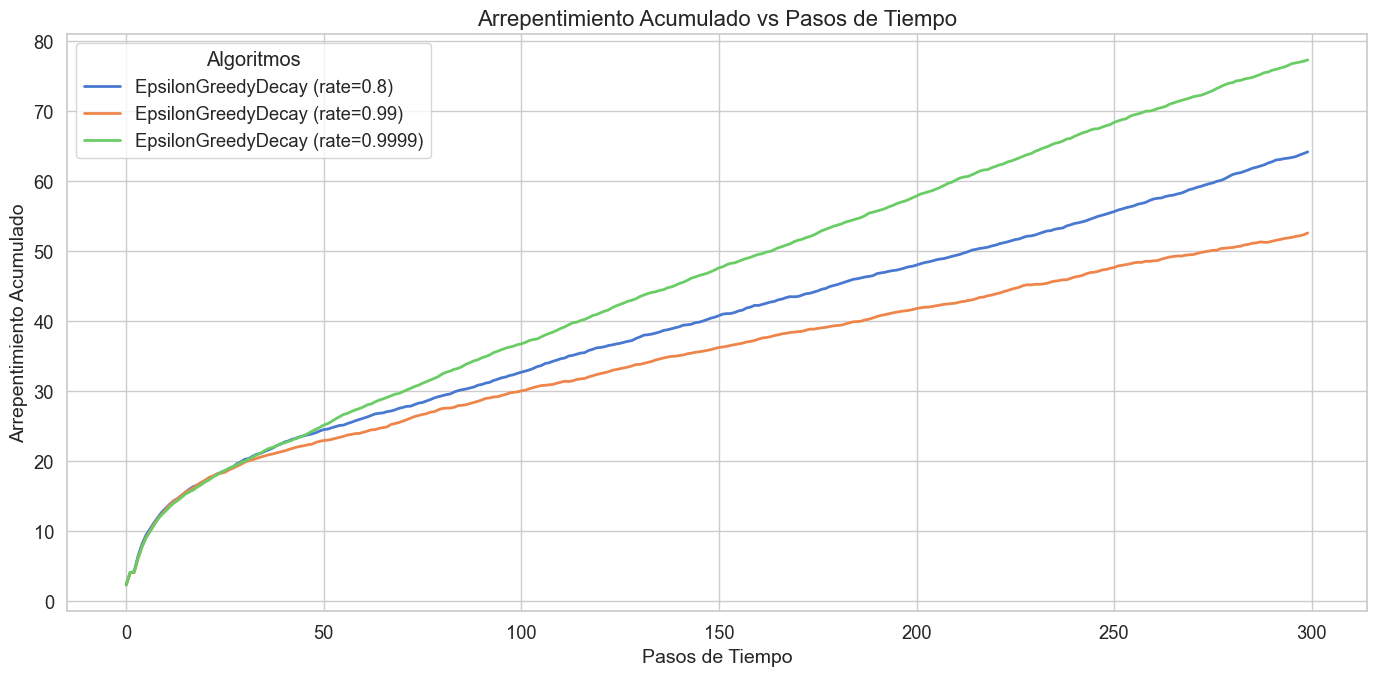

In [108]:
plot_regret(steps, cumulative_regret_per_algo_DN, algorithms_decay)

En la gráfica de arrepentimiento acumulado sí podemos apreciar con más claridad las diferencias en el rendimiento entre los tres algoritmos. Como vemos, la curva de *regret* del algoritmo con tasa igual a 0.99 se mantiene por debajo de las otras dos durante toda la ejecución, lo que indica que el agente ha sabido escoger consistentemente mejores brazos que los otros. La siguiente mejor tasa para el bandido de distribución normal es 0.8, mientras que $\lambda=0.9999$ es demasiado elevada, lo que provoca que el agente sea demasiado explorador y, por tanto, escoja brazos subóptimos con más frecuencia. Por consiguiente, su curva de arrepentimiento es la peor de las tres, llegando a un regret de casi 80 en la última iteración.

#### Análisis Detallado de Selecciones Óptimas

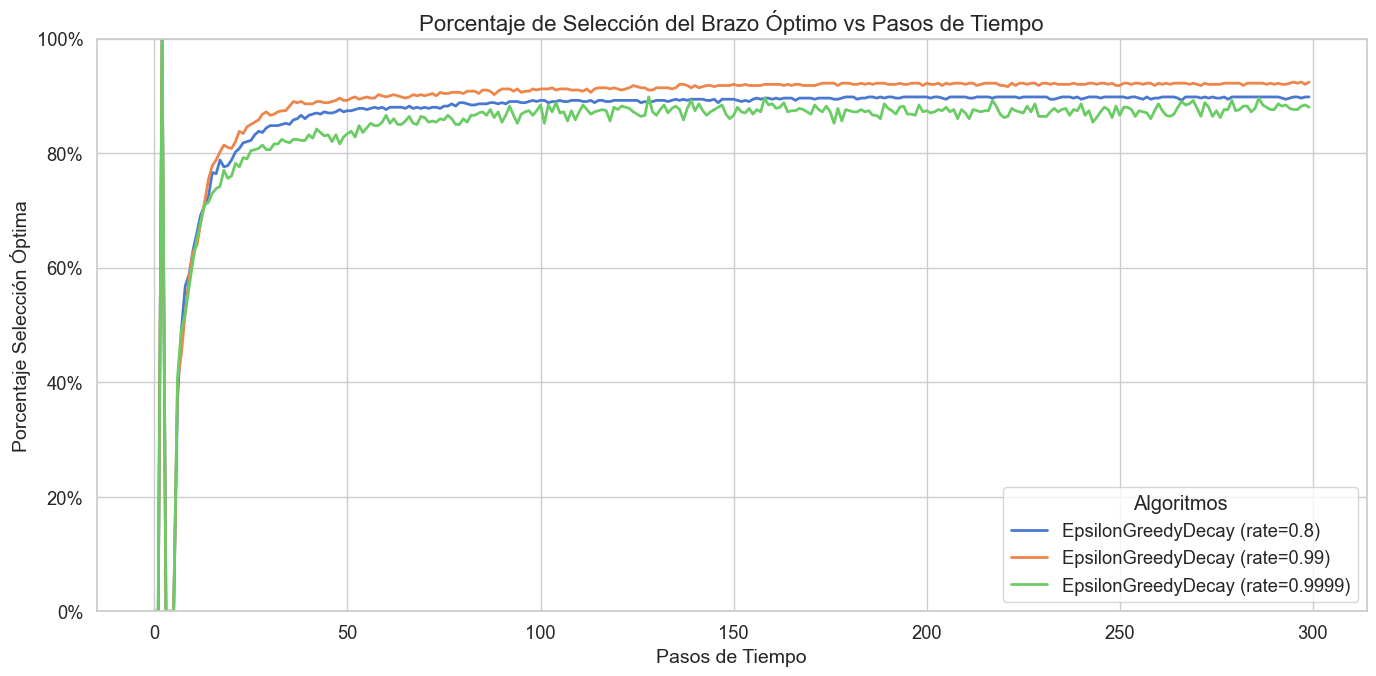

In [109]:
plot_optimal_selections(steps, optimal_selections_DN, algorithms_decay)

La gráfica de selecciones óptimas confirma lo que veíamos en el arrepentimiento acumulado: la tasa de 0.9999 produce los peores resultados, mientras que la mejor tasa, de 0.99, converge en el mayor porcentaje de selecciones óptimas de entre los tres, superior al 90%. De nuevo, son resultados muy similares a los que veíamos en el algoritmo Epsilon Greedy, por lo que el decaimiento no parece haber supuesto ninguna mejora en este caso.

#### Análisis Detallado de Estadísticas por Brazo

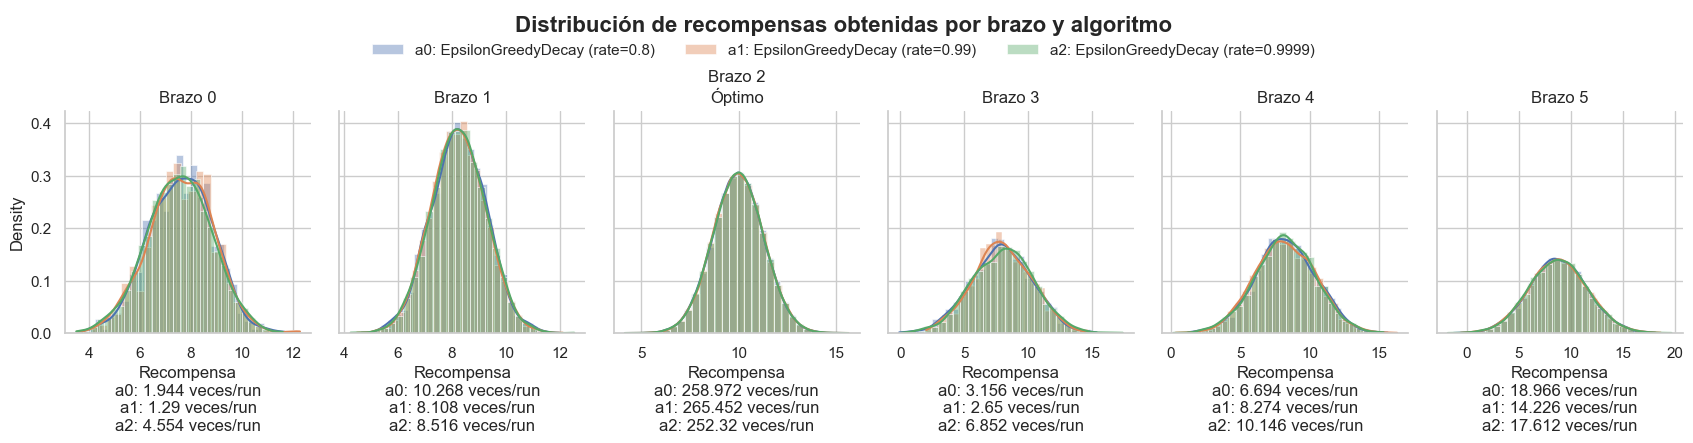

In [110]:
plot_arm_statistics(rewards_per_arm_per_algo_DN, algorithms_decay, runs, optimal_arm_normal)

El algoritmo con mayor tasa de decaimiento es el que más veces a escogido los peores brazos dada su mayor exploración continuada, mientras que el algoritmo con $\lambda=0.99$ ha logrado identificar exitosamente el brazo óptimo, escogiéndolo 265 veces de media, e ignorar el resto de brazos, siendo el que menos veces ha seleccionado los brazos subóptimos (a excepción del brazo 4).

### Distribución Binomial

Pasamos ahora al bandido con brazos de distribución binomial.

In [111]:
np.random.seed(SEMILLA)
rewards_DBi, optimal_selections_DBi, cumulative_regret_per_algo_DBi, rewards_per_arm_per_algo_DBi = run_experiment(bandit_binomial, algorithms_decay, steps, runs)

100%|██████████| 500/500 [00:21<00:00, 23.30it/s]


#### Análisis Detallado de Recompensa Promedio

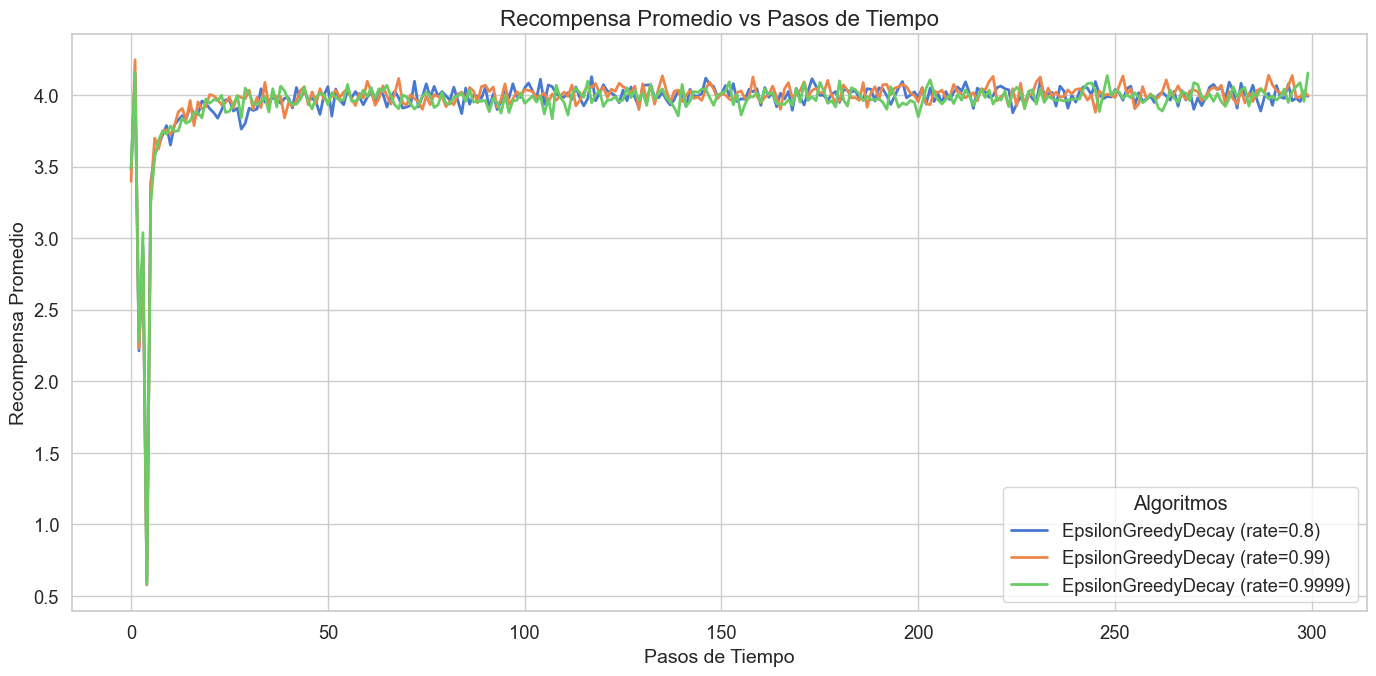

In [112]:
plot_average_rewards(steps, rewards_DBi, algorithms_decay)

Tal y como pasaba con el bandido normal, el binomial se comporta de manera muy similar con el algoritmo Epsilon Decay a como lo hacía con el Epsilon Greedy: las tres versiones han convergido rápidamente a una recompensa promedio alrededor de 4.0, muy próxima a la recompensa esperada óptima de 4.2.

#### Análisis Detallado de Regret Acumulado

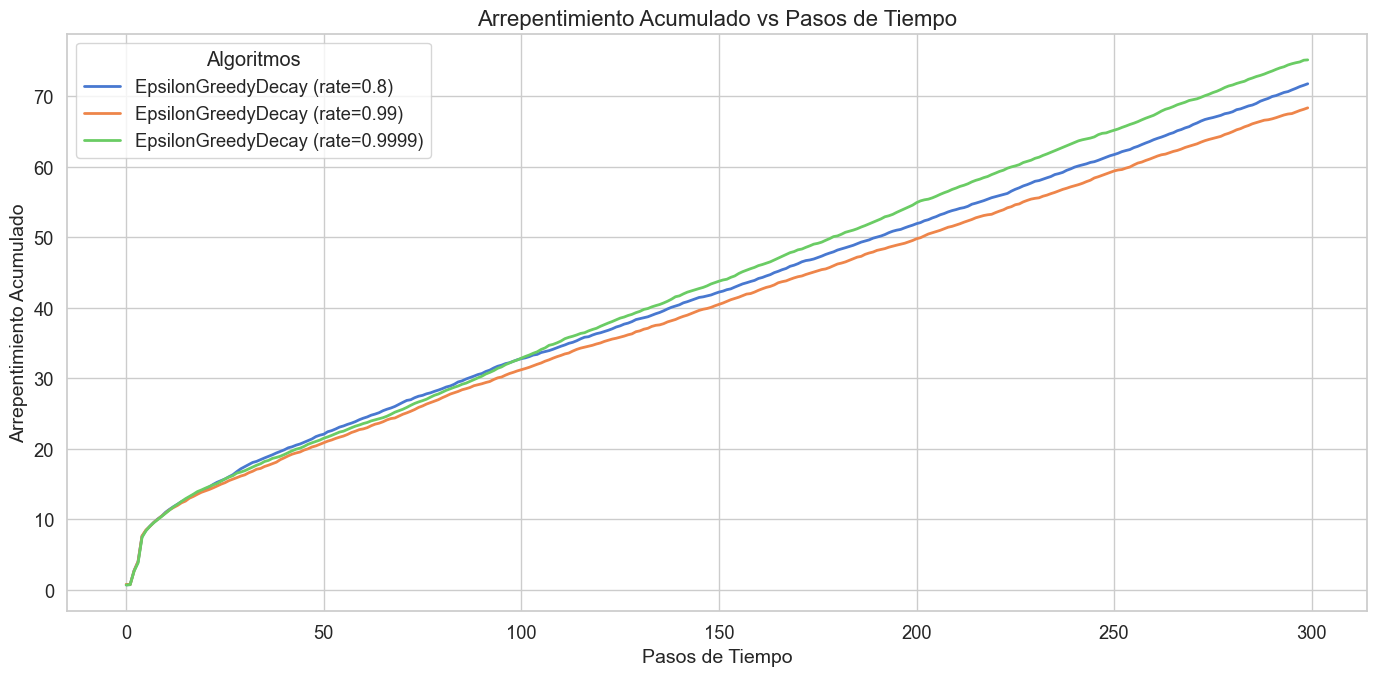

In [113]:
plot_regret(steps, cumulative_regret_per_algo_DBi, algorithms_decay)

El comportamiento de las tres versiones es aun más parecido entre sí que en el caso del Epsilon Greedy: las tres curvas de arrepentimiento son casi idénticas. Los resultados son ligeramente peores que con el Epsilon Greedy, puesto que en ese caso un $\epsilon$ constante de 0.01 nos daba un *regret* acumulado de algo más de 60 en la última iteración, mientras que en los Epsilon Decay el mejor arrepentimiento acumulado conseguido es de casi 70.

#### Análisis Detallado de Selecciones Óptimas

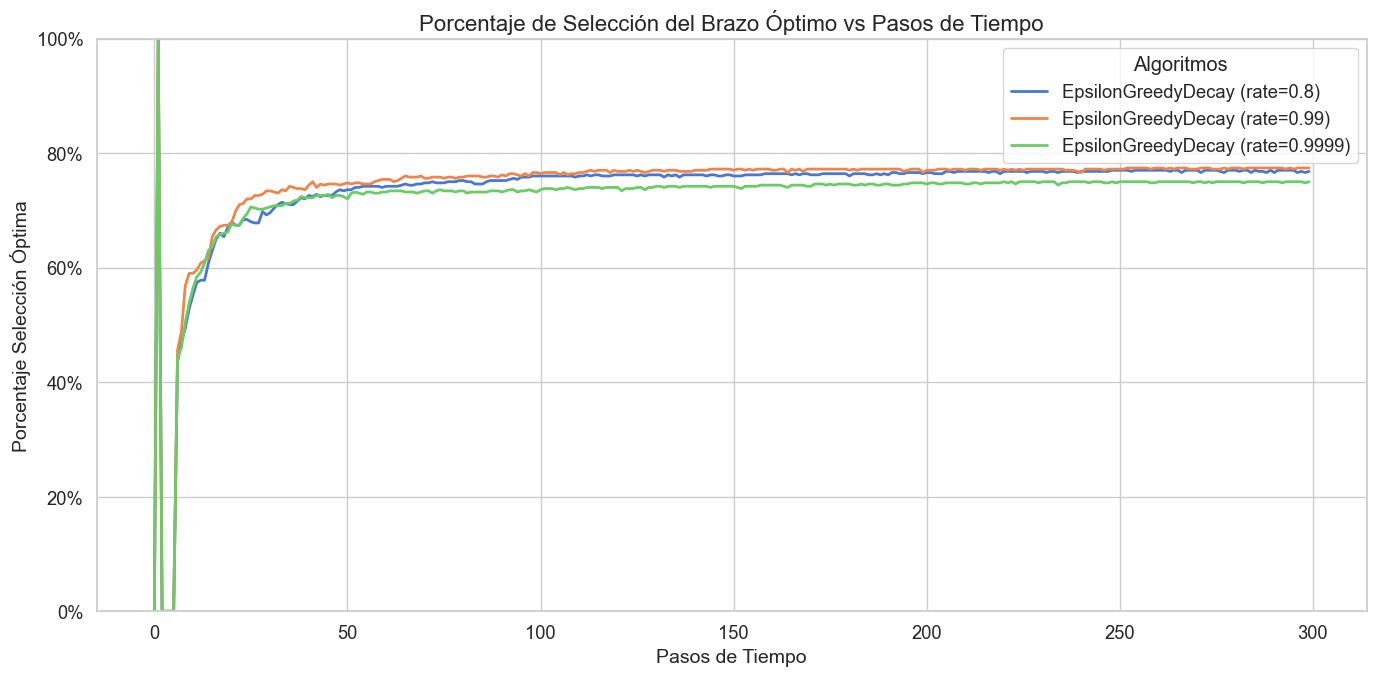

In [114]:
plot_optimal_selections(steps, optimal_selections_DBi, algorithms_decay)

Los tres algoritmos se estabilizan en un porcentaje de selección del brazo óptimo del 80%, aproximadamente.

#### Análisis Detallado de Estadísticas por Brazo

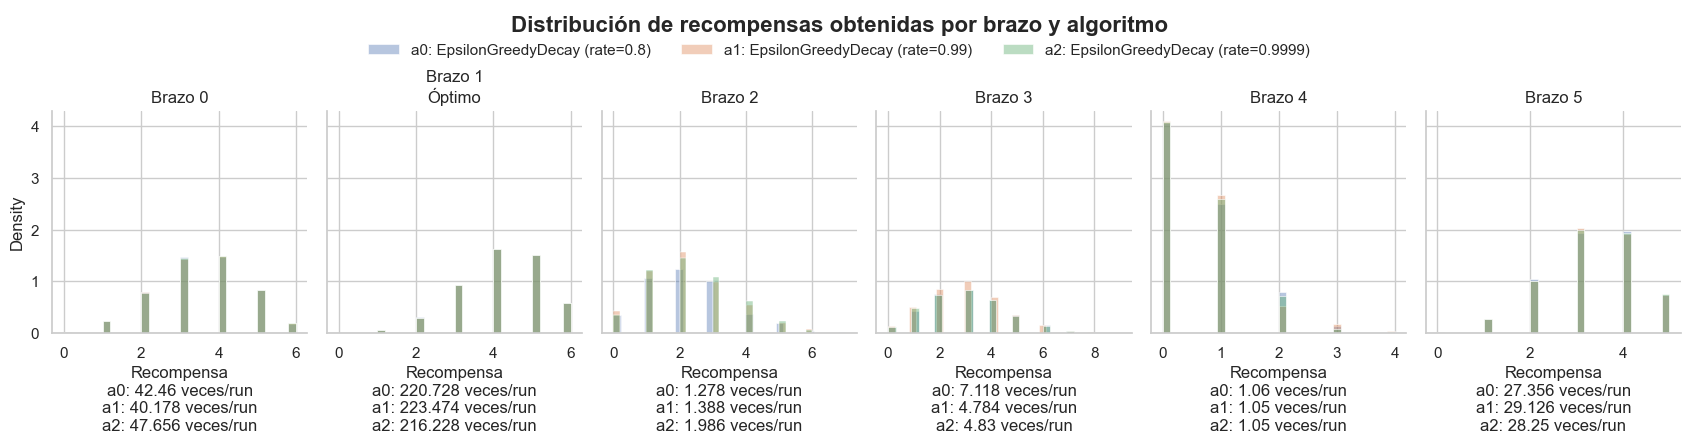

In [121]:
plot_arm_statistics(rewards_per_arm_per_algo_DBi, algorithms_decay, runs, optimal_arm_binomial, kde=False)

Como cabría esperar, el comportamiento de los tres algoritmos a la hora de seleccionar brazos ha sido muy similar, de tal forma que el número de veces que cada brazo ha sido escogido de media por cada algoritmo es casi idéntico, con el mejor brazo siendo escogido alrededor de 220 veces de media por ejecución y el peor brazo siendo elegido una sola vez (en la primera ronda de inicialización).

### Distribución Bernoulli

Por último, veamos cómo se comporta el $\epsilon$-decaimiento con la distribución Bernoulli.

In [116]:
np.random.seed(SEMILLA)
rewards_DBe, optimal_selections_DBe, cumulative_regret_per_algo_DBe, rewards_per_arm_per_algo_DBe = run_experiment(bandit_bernoulli, algorithms_decay, steps, runs)

100%|██████████| 500/500 [00:21<00:00, 23.30it/s]


#### Análisis Detallado de Recompensa Promedio

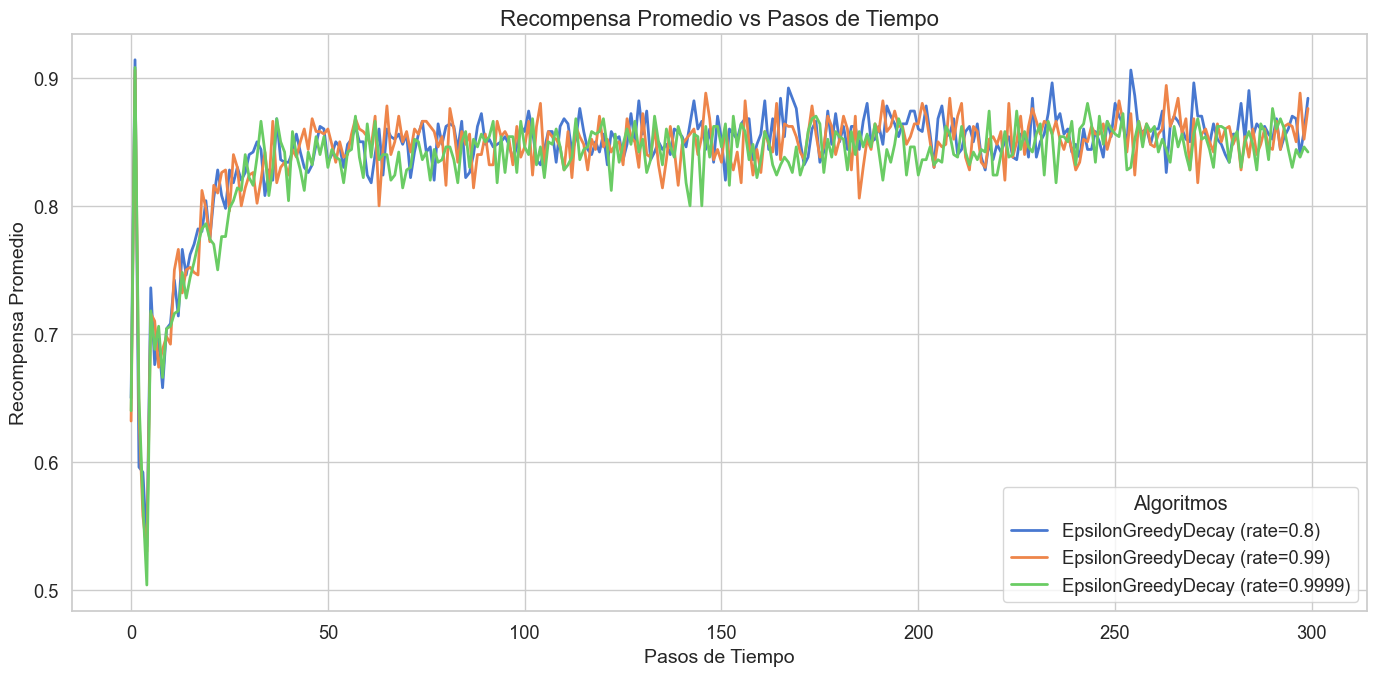

In [117]:
plot_average_rewards(steps, rewards_DBe, algorithms_decay)

Como vemos, el comportamiento de la recompensa promedio es más errático debido a la naturaleza binaria de la distribución Bernoulli, al igual que pasaba en los Epsilon Greedy. Si comparamos esta gráfica con la obtenida en el Epsilon Greedy, vemos que el aprendizaje en el caso del Epsilon Decay es más lento debido a que se realiza una mayor exploración en los primeros pasos y, por tanto, no se le permite al agente centrarse únicamente en el brazo que considera mejor. No obstante, el resultado final es muy parecido: los tres algoritmos se estabilizan en una recompensa promedio alrededor de 0.85, siendo la máxima recompensa esperada de 0.9.

#### Análisis Detallado de Regret Acumulado

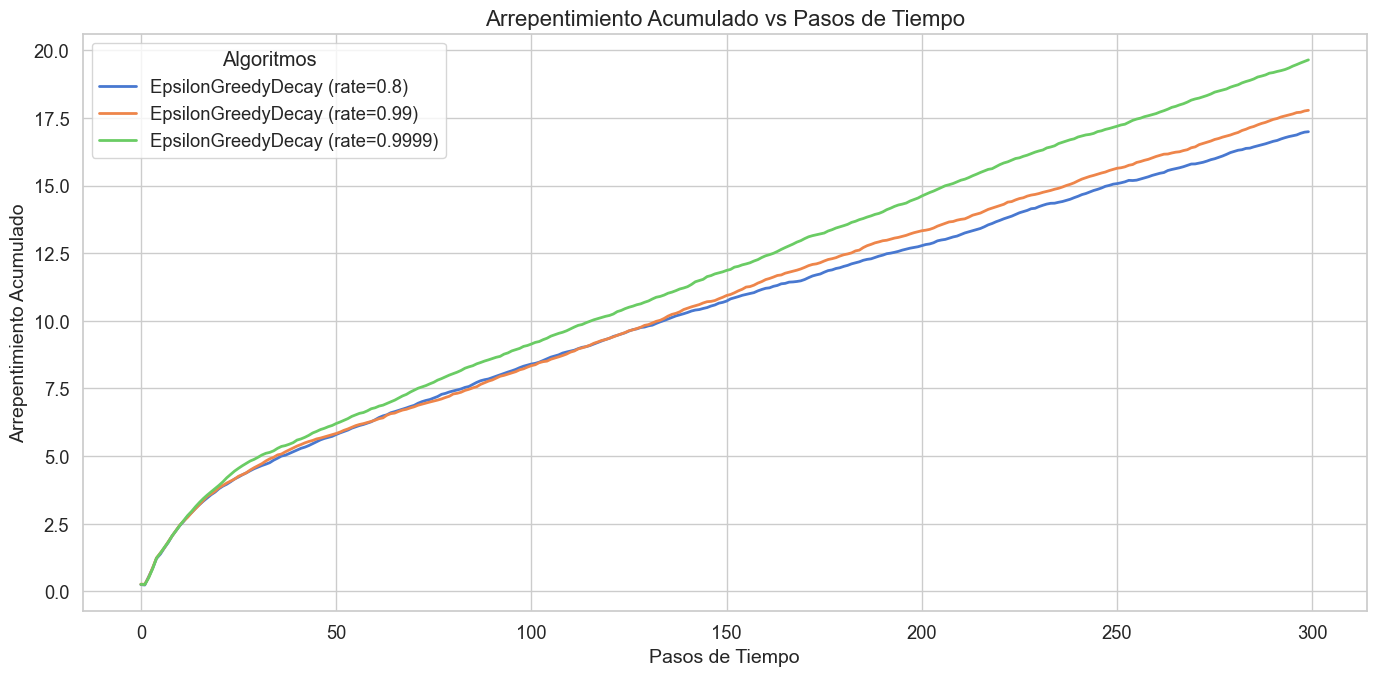

In [118]:
plot_regret(steps, cumulative_regret_per_algo_DBe, algorithms_decay)

El comportamiento del *regret* acumulado es similar en los tres casos, si bien la tasa de 0.9999 sigue siendo la que ofrece peores resultados. En este caso, la tasa de 0.8 parece la mejor, aunque apenas difiere de $\lambda=0.9$.

#### Análisis Detallado de Selecciones Óptimas

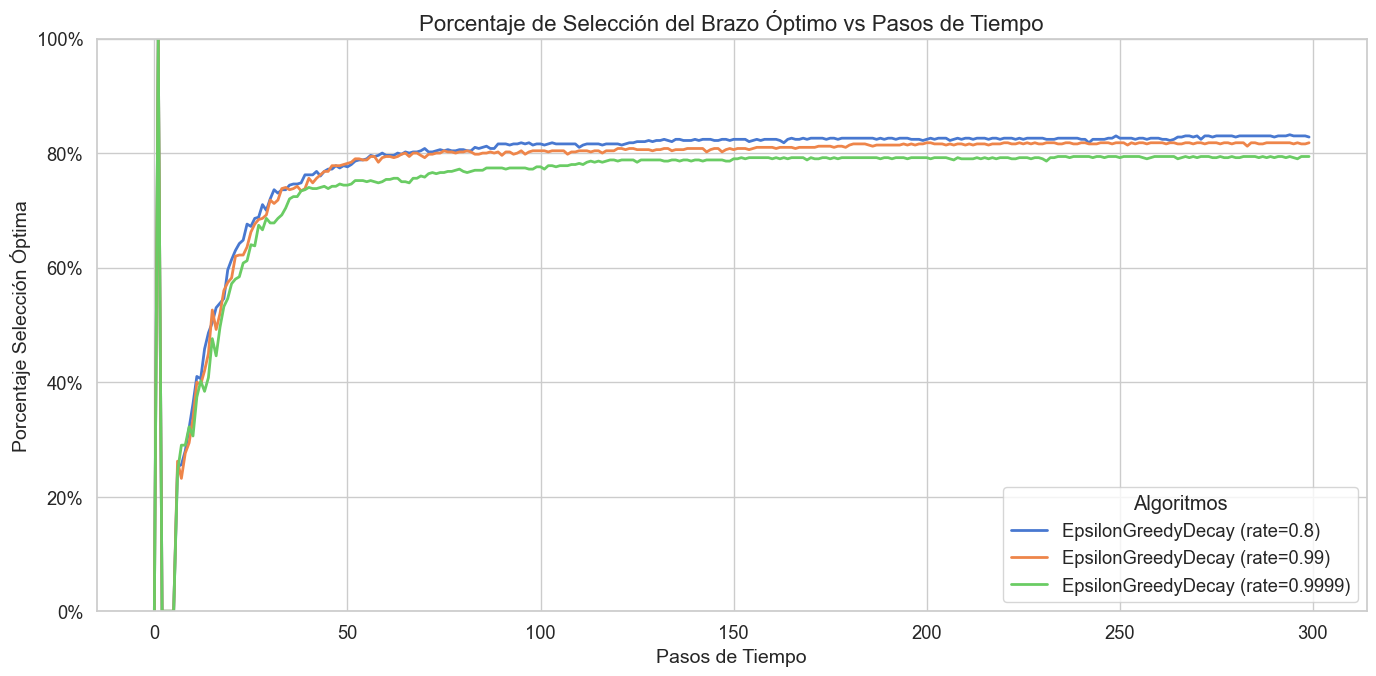

In [119]:
plot_optimal_selections(steps, optimal_selections_DBe, algorithms_decay)

Esta gráfica tiene una forma bastante diferente de la gráfica análoga de los algoritmos Epsilon Greedy, dado que no se observa un valle al principio sino que los tres algoritmos aprenden de manera progresiva y ascendente, estabilizándose sobre la iteración 50. Sin embargo, parece que los algoritmos dejan de aprender por completo y se estancan en un porcentaje de selección del 80%, mientras que en los Epsilon Greedy sí parecían seguir mejorando lentamente, en especial aquel con $\epsilon=0.1$. Esto se debe a que hemos fijado el $\epsilon_{min}$ en 0.001 pensando en que los agentes ya habrían aprendido lo suficiente con anterioridad, pero parece que sería necesario incrementar el valor del epsilon mínimo para permitir un mayor aprendizaje.

#### Análisis Detallado de Estadísticas por Brazo

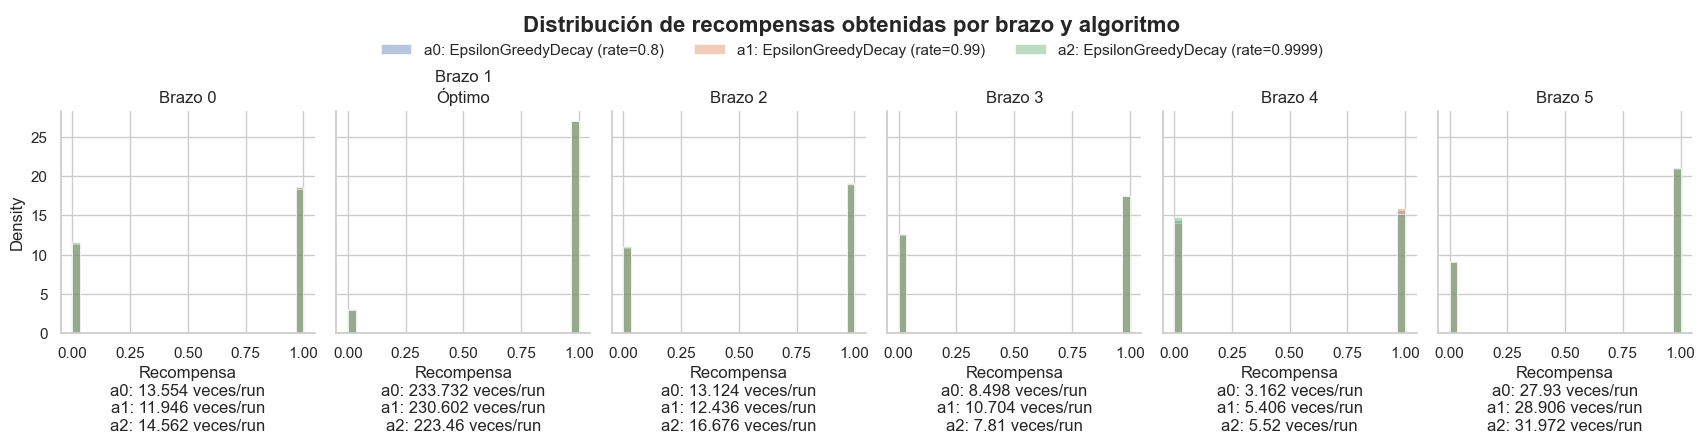

In [122]:
plot_arm_statistics(rewards_per_arm_per_algo_DBe, algorithms_decay, runs, optimal_arm_bernoulli, kde=False)

Vemos que el brazo óptimo ha sido elegido en más de 220 ocasiones por los tres algoritmos, con el algoritmo de $\lambda=0.8$ seleccionándolo en 233 ocasiones. El segundo mejor brazo también ha sido elegido bastantes veces por las tres versiones, y el algoritmo con mayor exploración ($\lambda=0.9999$) es el que más veces ha elegido el peor brazo.

## Conclusiones

A lo largo de este notebook, hemos explorado el rendimiento del algoritmo **Epsilon-Greedy** y del **Epsilon-Decay** en el problema del bandido multibrazo, evaluando su comportamiento bajo tres distribuciones de recompensa distintas: Normal, Binomial y Bernoulli.

Los hallazgos principales se pueden resumir en los siguientes puntos:

1.  **El Dilema Exploración-Explotación**: Hemos comprobado empíricamente que existe un compromiso fundamental entre adquirir nueva información (exploración) y capitalizar el conocimiento actual (explotación).
    *   **$\epsilon=0$ (Greedy)**: Es una estrategia arriesgada. Aunque puede funcionar si las condiciones iniciales son favorables, a menudo converge prematuramente a óptimos locales, resultando en un desempeño subóptimo a largo plazo.
    *   **$\epsilon=0.1$ (Exploración Moderada)**: Aprende muy rápido al inicio, pero sufre de un "costo de exploración" asintótico. Nunca deja de explorar, lo que impide que la selección de la acción óptima supere el 90%.
    * En nuestro caso, no ha habido diferencias muy significativas entre todas las tasas de exploración, aunque un $\epsilon$ de entre 0.01 y 0.1 ha solido funcionar bastante bien, permitiendo un aprendizaje continuo durante toda la ejecución.

2.  **Decaimiento del epsilon**: Para las distribuciones que hemos probado, un decaimiento del parámetro epsilon no ha logrado obtener mejores resultados, de hecho, en ocasiones el rendimiento de los algoritmos ha sido peor que en los algoritmos Epsilon Greedy. Esto podría deberse a que la fase de inicialización que realizamos ya ofrece la suficiente información a los agentes como para que no sea necesario realizar una mayor exploración al principio. Además, es posible que un valor diferente de $\epsilon_{min}$ hubiese generado mejores resultados, dado que el valor de 0.001 podría ser demasiado pequeño y, por ende, no permitir a los agentes continuar con su aprendizaje.

Por último, en el enunciado se pide indicar cuál de las gráficas mostradas es la más relevante o informativa. A este respecto, consideramos que la gráfica de **arrepentimiento** es la que muestra con mayor claridad las diferencias en el rendimiento de cada algoritmo. En la gráfica de recompensas promedio resulta a menudo difícil de discernir qué algoritmo se comporta mejor, mientras que en la gráfica de arrepentimiento las curvas suelen estar lo suficientemente separadas como para verlo con claridad. Además, no hace falta conocer cuál es la recompensa óptima: un arrepentimiento de cero siempre será lo mejor, independientemente de las recompensas que generen los brazos. Por último, nos permite ver qué agentes han sabido identificar cuáles son los mejores brazos y comprobar si han seguido aprendiendo durante toda la ejecución (si su curva se hace cada vez más horizontal).

## Referencias


<span id="apuntes">[1]</span> Hernández Molinero, L. D. (2025), *"Aprendizaje por Refuerzo. Bandido Multibrazo"*. Universidad de Murcia.

<span id="suttonbarto">[2]</span> Sutton, R., Barto, A. (2018), *"Reinforcement Learning, second edition: An Introduction"*. MIT Press.
